In [9]:
import astropy.units as u
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from astropy import constants as const

from castor_etc.background import Background
from castor_etc.photometry import Photometry
from castor_etc.sources import ExtendedSource, GalaxySource, PointSource
from castor_etc.telescope import Telescope
from castor_etc.uvmos_spectroscopy import UVMOS_Spectroscopy

In [10]:
MyTelescope = Telescope()
MyTelescope = Telescope(read_noise=2.0)
MyBackground = Background()

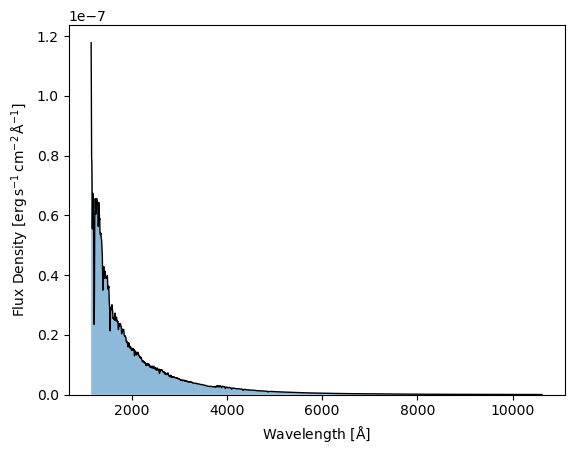

In [12]:
MySource = PointSource()
#
# Approximate the star as a blackbody with a temperature of 8000 K. By default, the
# spectral radiance of the blackbody (erg/s/cm^2/A/sr) is normalized to a star of 1 solar
# radius at 1 kpc distance to get the flux density in erg/s/cm^2/A (this can be changed
# via the `radius` and `dist` parameters).
# Note that only the temperature is required below, but some others are shown for
# illustration.
#

# Blackbody
#MySource.generate_bb(20000 * u.K)
#MySource.norm_to_AB_mag(10)

MySource.use_pickles_spectrum("b0v")
MySource.norm_to_AB_mag(1)
MySource.show_spectrum()

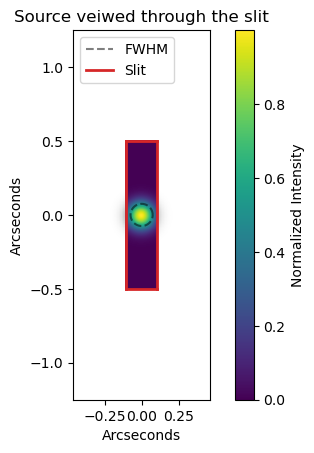

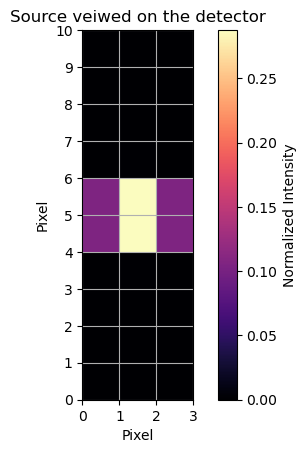

In [13]:
MySpec = UVMOS_Spectroscopy(MyTelescope, MySource, MyBackground)


#
# Specify the slit
#
MySpec.specify_slit()

#MySpec.specify_slit(slit_width = 0.5 * u.arcsec, slit_height = 0.25 * u.arcsec   )
# 
# Optional: Show the source as viewed through the slit
#
MySpec.show_slit()

#
# Optional: Show a single image of the slit on the detector
#

MySpec.show_source_pix_weights()


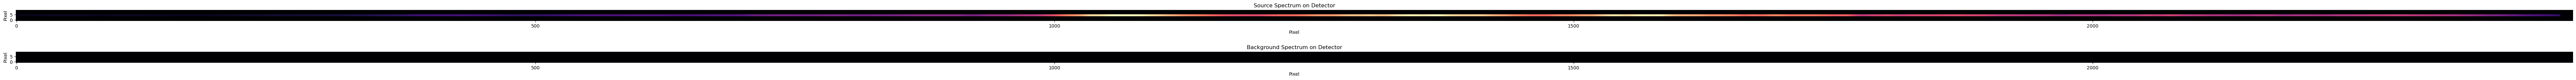

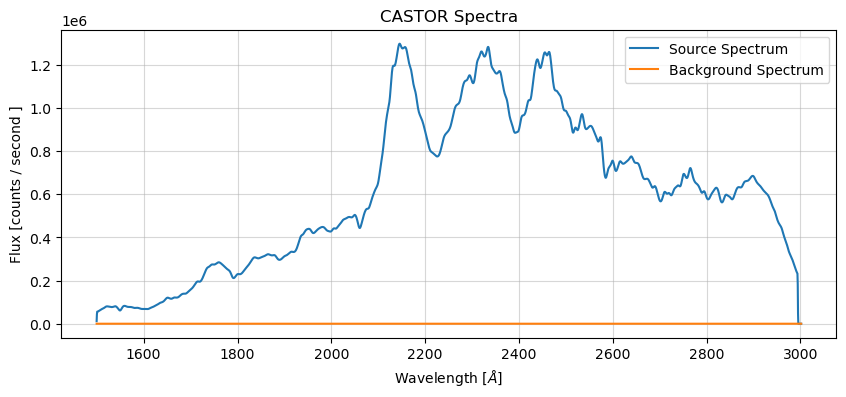

In [14]:
MySpec.calc_source_CASTORSpectrum(extraction_width=1, extraction_lowerlim=4, extraction_upperlim = 7)
MySpec.calc_background_CASTORSpectrum(extraction_width=1, extraction_lowerlim=4, extraction_upperlim = 7)
#
# Optional: Visualize the source and background spectra on the detector
#
plt.figure(figsize=(100,3))

ax1 = plt.subplot(211)
plt.imshow(MySpec.source_detector,origin='lower',cmap='magma',aspect='auto')
plt.title('Source Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax1.set_aspect('equal')


ax2 = plt.subplot(212, sharex=ax1, sharey=ax1)
plt.imshow(MySpec.background_detector*MySpec.source_extracted_numpixs,origin='lower',cmap='magma',aspect='auto', vmin=min(MySpec.source_detector.flatten()), vmax=max(MySpec.source_detector.flatten()))
plt.title('Background Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax2.set_aspect('equal')
#
# Optional: Visualize the source and background 
#
plt.figure(figsize=(10,4))
ax = plt.subplot(111)
plt.plot(MySpec.waves_CASTORSpectrum, MySpec.source_CASTORSpectrum,'-',label='Source Spectrum')

plt.plot(MySpec.waves_CASTORSpectrum, MySpec.background_CASTORSpectrum*MySpec.source_extracted_numpixs,'-',label='Background Spectrum')

plt.title('CASTOR Spectra')
plt.xlabel('Wavelength '+r'[$\AA$]')
plt.ylabel('Flux [counts / second ]')
plt.grid(alpha=0.5)
plt.legend()
plt.savefig('Spectra_Proxi.png')

In [15]:
MySpec.calc_t_from_snr(10, 2000)

array(0.00474686)